In [ ]:
import os
os.environ["KAGGLE_TOKEN"] = "KGAT_640c33a8b708d8a5117db2c15af1882f"

import kagglehub
path = kagglehub.dataset_download("aureliofoni/nikeshoes-counterfeit")
print("Path to dataset files:", path)

100%|██████████| 187M/187M [00:01<00:00, 174MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aureliofoni/nikeshoes-counterfeit/versions/1


In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/aureliofoni/nikeshoes-counterfeit/versions/1"

# Check what's inside
for folder in os.listdir(dataset_path):
    print(folder)

README.roboflow.txt
train
valid
README.dataset.txt
data.yaml
test


In [ ]:
!pip install ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.5 MB/s eta 0:00:00


In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/aureliofoni/nikeshoes-counterfeit/versions/1"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')

1/
  train/
    images/
    labels/
  valid/
    images/
    labels/
  test/
    images/
    labels/


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo12n.pt")  # nano variant, can use yolo12s/m/l/x for larger

model.train(
    data=f"{dataset_path}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="nike_counterfeit",
    name="yolo12_run1"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/aureliofoni/nikeshoes-counterfeit/versions/1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, free

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b565cd6cef0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree(
    "/content/runs/detect/nike_counterfeit/yolo12_run1",
    "/content/drive/MyDrive/nike_counterfeit/yolo12_run1"
)
print("✅ Model saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved to Google Drive!


Running predictions on test set...
Results saved to /content/simulation/predictions
✅ Done! 386 images processed.


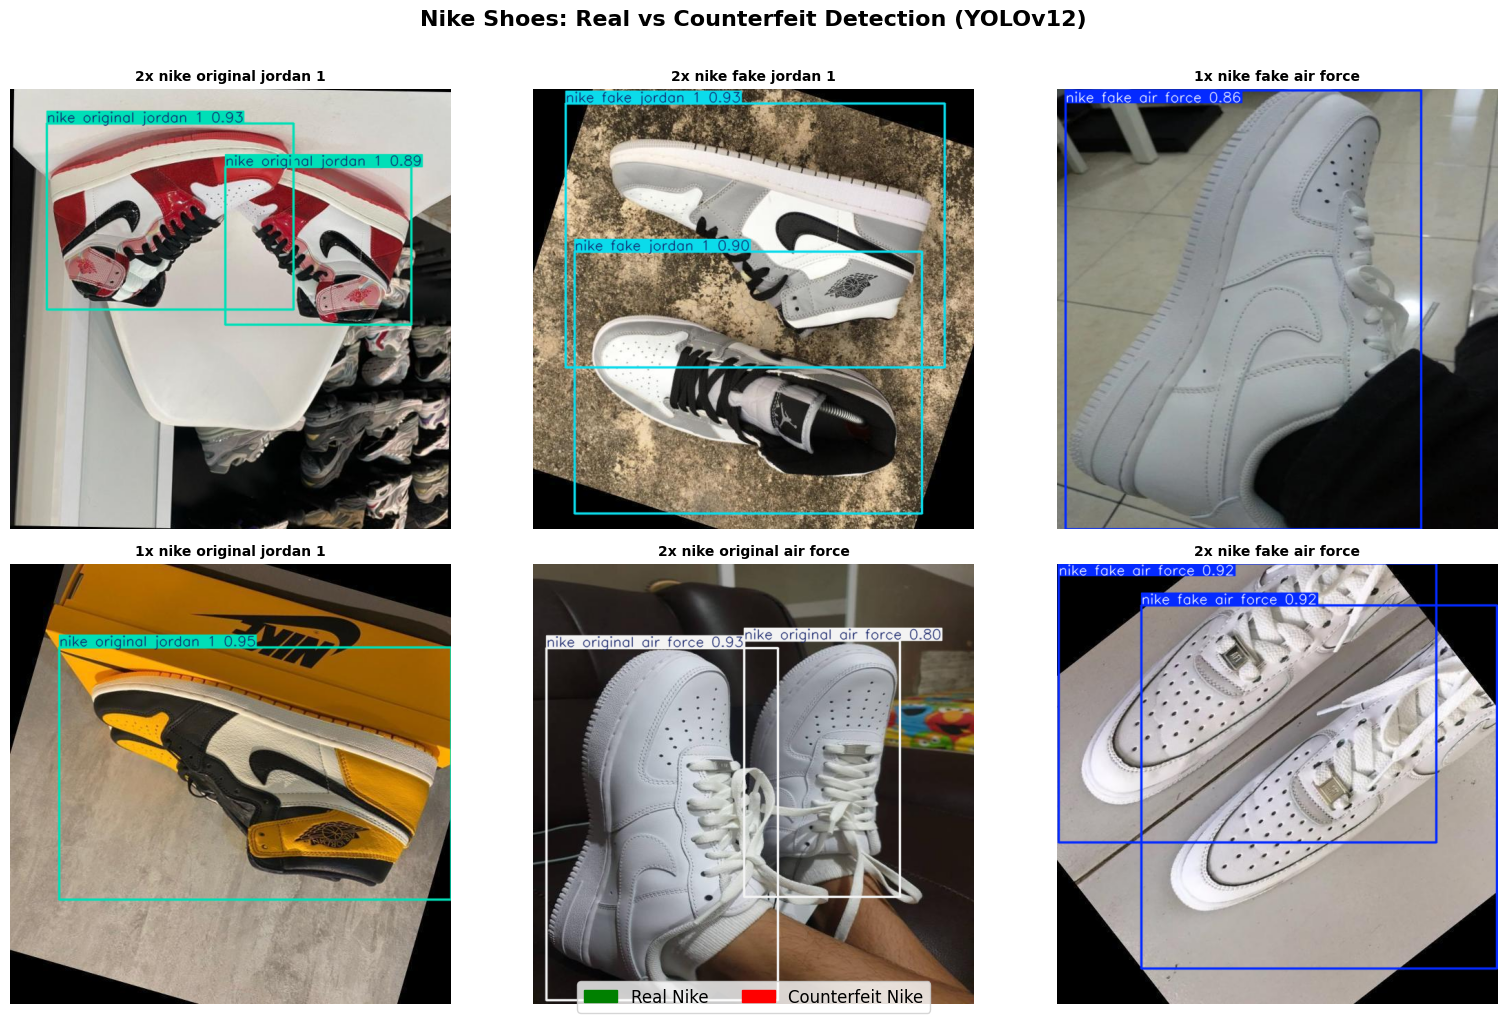


📊 Detection Summary:
   Real detections  : 0
   Fake detections  : 627
   Total images     : 386

📁 Saved annotated images: /content/simulation/predictions/


In [ ]:
# ============================================================
# NIKE COUNTERFEIT DETECTION - SIMULATION & VISUALIZATION
# ============================================================

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import random

# ── 1. Load trained model ───────────────────────────────────
model = YOLO("/content/runs/detect/nike_counterfeit/yolo12_run1/weights/best.pt")

# ── 2. Run prediction on full test set ──────────────────────
print("Running predictions on test set...")
results = model.predict(
    source=f"{dataset_path}/test/images",
    conf=0.5,
    iou=0.45,
    save=True,
    project="/content/simulation",
    name="predictions",
    verbose=False
)
print(f"✅ Done! {len(results)} images processed.")

# ── 3. Pick 6 random test images to visualize ───────────────
test_images = os.listdir(f"{dataset_path}/test/images")
sample_images = random.sample(test_images, min(6, len(test_images)))

# ── 4. Plot grid with bounding boxes ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, img_name in enumerate(sample_images):
    img_path = f"{dataset_path}/test/images/{img_name}"

    result = model.predict(img_path, conf=0.5, verbose=False)[0]
    annotated = result.plot()  # bounding boxes + labels drawn
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    # Count detections per class
    class_counts = {}
    for box in result.boxes:
        cls_name = model.names[int(box.cls)]
        class_counts[cls_name] = class_counts.get(cls_name, 0) + 1

    label = ", ".join([f"{v}x {k}" for k, v in class_counts.items()]) or "No detection"

    axes[i].imshow(annotated_rgb)
    axes[i].axis("off")
    axes[i].set_title(label, fontsize=10, fontweight='bold')

# ── 5. Legend & title ────────────────────────────────────────
real_patch  = mpatches.Patch(color='green', label='Real Nike')
fake_patch  = mpatches.Patch(color='red',   label='Counterfeit Nike')
fig.legend(handles=[real_patch, fake_patch], loc='lower center',
           ncol=2, fontsize=12, frameon=True)

plt.suptitle("Nike Shoes: Real vs Counterfeit Detection (YOLOv12)",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── 6. Print summary stats ───────────────────────────────────
print("\n📊 Detection Summary:")
total_real = total_fake = 0
for r in results:
    for box in r.boxes:
        cls_name = model.names[int(box.cls)]
        if "real" in cls_name.lower():
            total_real += 1
        else:
            total_fake += 1

print(f"   Real detections  : {total_real}")
print(f"   Fake detections  : {total_fake}")
print(f"   Total images     : {len(results)}")
print(f"\n📁 Saved annotated images: /content/simulation/predictions/")

Saving adwdad.webp to adwdad.webp

image 1/1 /content/adwdad.webp: 480x640 1 nike original air force, 65.7ms
Speed: 2.2ms preprocess, 65.7ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)


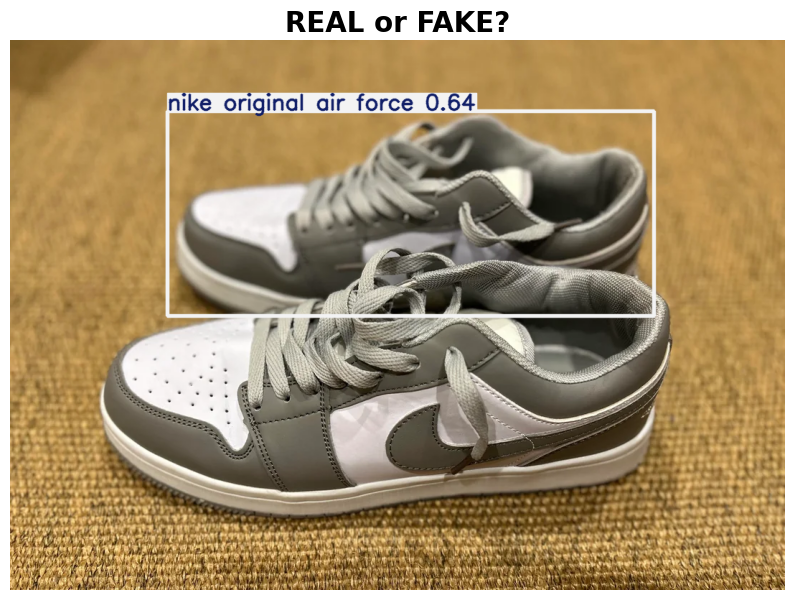

In [ ]:
from google.colab import files
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt

model = YOLO("/content/drive/MyDrive/nike_counterfeit/yolo12_run1/weights/best.pt")

# Upload any image from your phone/laptop
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

result = model.predict(img_path, conf=0.5)[0]
annotated = result.plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("REAL or FAKE?", fontsize=20, fontweight='bold')
plt.show()